# 03 - Modeling: Baseline

**Goal:** Train a baseline model using only `baselines.csv` merged with `customers.csv`, 
as recommended by the Data Dictionary. This gives us a performance floor to beat before 
introducing the full engineered feature matrix.

**Evaluation metric:** AUC-ROC on the val split (200 customers, 9 suspicious). 
This is the same metric the organisers use on the test set, so it is the right thing to optimise.

**Workflow:**
1. Baseline model on `baselines.csv` features only
2. Inspect feature importance and PR curve
3. Record val AUC-ROC as the floor — engineered features must beat this

> Train split: 500 customers (21 suspicious). Val split: 200 customers (9 suspicious). 
Test split: 500 customers (labels withheld by organisers — used only for final submission).

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

DATA = '../data/raw/'
OUT  = '../data/'

---
## 1. Load & Merge Baseline Features

Merging `baselines.csv` (9 pre-computed behavioural features) directly with `customers.csv` 
(static profile features). This is the fastest viable model — no raw transaction engineering needed. 
We also include the static customer-level signals that EDA confirmed are available without computation: 
customer type and KYC rating.

In [2]:
customers = pd.read_csv(DATA + 'customers.csv')
baselines = pd.read_csv(DATA + 'baselines.csv')

df = customers.merge(baselines, on='customer_id', how='left')

# Static features confirmed available without leakage
static_features = [
    'customer_type',
    'kyc_risk_rating',
    'pep_status',
    'sanctions_screening_flag',
    'num_accounts',
]

baseline_features = [
    'avg_monthly_transaction_count',
    'avg_monthly_volume',
    'max_single_transaction_6m',
    'pct_international_transactions',
    'pct_cash_transactions',
    'num_unique_counterparties_6m',
    'transaction_time_entropy',
    'geographic_spread_score',
    'dormancy_periods_count',
]

all_features = static_features + baseline_features

# Encode categoricals
df['kyc_medium']    = (df['kyc_risk_rating'] == 'medium').astype(int)
df['kyc_high']      = (df['kyc_risk_rating'] == 'high').astype(int)
df['pep_status']    = df['pep_status'].astype(int)
df['sanctions_screening_flag'] = df['sanctions_screening_flag'].astype(int)

type_dummies = pd.get_dummies(df['customer_type'], prefix='type', drop_first=False)
df = pd.concat([df, type_dummies], axis=1)

feature_cols = [
    'kyc_medium', 'kyc_high', 'pep_status', 'sanctions_screening_flag', 'num_accounts',
    'type_corporate', 'type_SME', 'type_sole_trader', 'type_personal',
] + baseline_features

print(f'Features: {len(feature_cols)}')
print(feature_cols)

Features: 18
['kyc_medium', 'kyc_high', 'pep_status', 'sanctions_screening_flag', 'num_accounts', 'type_corporate', 'type_SME', 'type_sole_trader', 'type_personal', 'avg_monthly_transaction_count', 'avg_monthly_volume', 'max_single_transaction_6m', 'pct_international_transactions', 'pct_cash_transactions', 'num_unique_counterparties_6m', 'transaction_time_entropy', 'geographic_spread_score', 'dormancy_periods_count']


In [3]:
train = df[df['split'] == 'train'].copy()
val   = df[df['split'] == 'val'].copy()

X_train = train[feature_cols].fillna(train[feature_cols].median())
y_train = train['suspicious_activity_confirmed'].astype(int)

X_val = val[feature_cols].fillna(train[feature_cols].median())
y_val = val['suspicious_activity_confirmed'].astype(int)

print(f'Train: {len(X_train)} rows, {y_train.sum()} suspicious ({y_train.mean():.1%})')
print(f'Val:   {len(X_val)} rows, {y_val.sum()} suspicious ({y_val.mean():.1%})')

Train: 500 rows, 21 suspicious (4.2%)
Val:   200 rows, 9 suspicious (4.5%)


---
## 2. Model 1 — Logistic Regression

**Why start here:** Logistic regression is the most interpretable model available. 
With only 21 suspicious training examples, a simple model is less likely to overfit than a complex one. 
It also gives us calibrated probabilities out of the box, which matters since AUC-ROC is our metric. 
We use `class_weight='balanced'` to compensate for the 5% imbalance — without it, the model 
would predict clean for everyone and achieve 95% accuracy while being useless.

In [4]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

lr_val_proba = lr.predict_proba(X_val_s)[:, 1]
lr_auc  = roc_auc_score(y_val, lr_val_proba)
lr_prauc = average_precision_score(y_val, lr_val_proba)

print(f'Logistic Regression — Val AUC-ROC: {lr_auc:.4f}  |  PR-AUC: {lr_prauc:.4f}')

Logistic Regression — Val AUC-ROC: 0.6824  |  PR-AUC: 0.0993


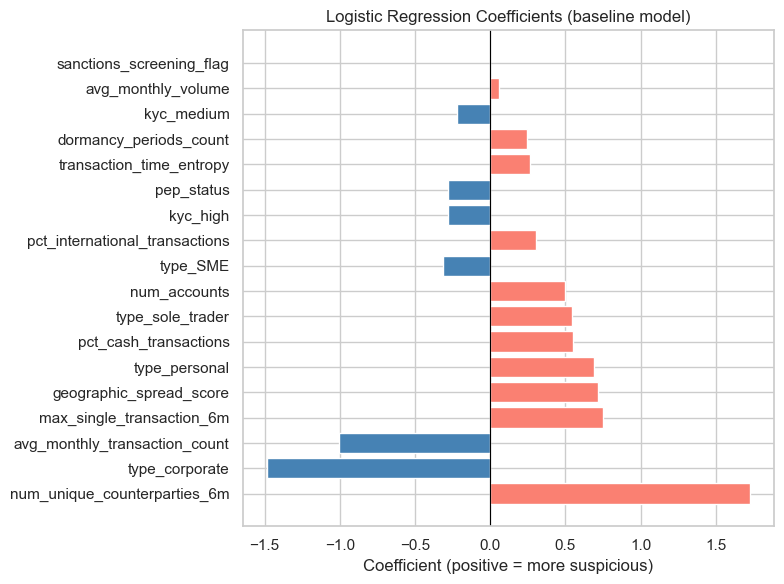

In [5]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['salmon' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients (baseline model)')
ax.set_xlabel('Coefficient (positive = more suspicious)')
plt.tight_layout()
plt.show()

---
## 3. Model 2 — Gradient Boosting Classifier

**Why:** Gradient boosting handles non-linear relationships and feature interactions that logistic 
regression cannot capture — for example, high volume is only suspicious when combined with high 
geographic spread. It also handles the mixed feature types (continuous + binary) without needing 
scaling.

We keep the model deliberately shallow (`max_depth=3`, low `n_estimators`) to avoid overfitting 
on 21 positive examples. We use `subsample=0.8` for stochastic gradient boosting which adds 
regularisation. Class imbalance is handled via `scale_pos_weight` equivalent through sample weighting.

In [6]:
sample_weight = np.where(y_train == 1,
    len(y_train) / (2 * y_train.sum()),
    len(y_train) / (2 * (len(y_train) - y_train.sum()))
)

gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42
)
gb.fit(X_train, y_train, sample_weight=sample_weight)

gb_val_proba = gb.predict_proba(X_val)[:, 1]
gb_auc  = roc_auc_score(y_val, gb_val_proba)
gb_prauc = average_precision_score(y_val, gb_val_proba)

print(f'Gradient Boosting   — Val AUC-ROC: {gb_auc:.4f}  |  PR-AUC: {gb_prauc:.4f}')

Gradient Boosting   — Val AUC-ROC: 0.7138  |  PR-AUC: 0.1459


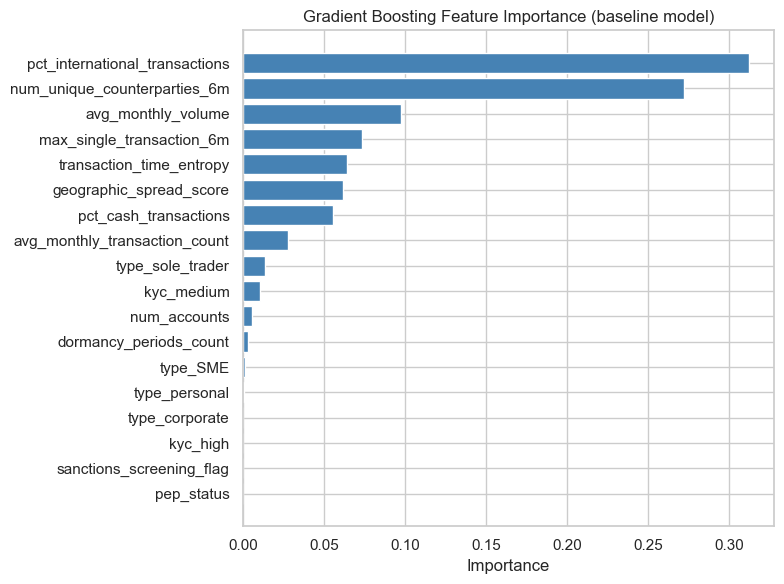

In [7]:
imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp_df['feature'], imp_df['importance'], color='steelblue', edgecolor='white')
ax.set_title('Gradient Boosting Feature Importance (baseline model)')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 4. Compare Models & Set the Floor

Both ROC and Precision-Recall curves plotted together. 
The PR curve matters more here given the 4.5% class imbalance — a model that ranks the 9 suspicious 
val customers highly will show a high area under the PR curve even if its ROC looks similar to a naive model.

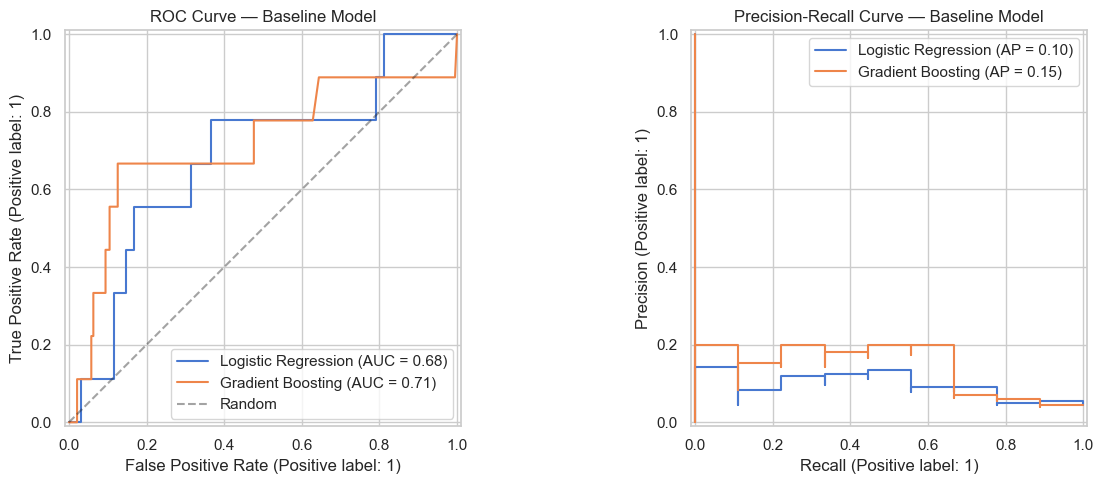

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(y_val, lr_val_proba, name='Logistic Regression', ax=axes[0])
RocCurveDisplay.from_predictions(y_val, gb_val_proba, name='Gradient Boosting', ax=axes[0])
axes[0].plot([0,1],[0,1],'k--',alpha=0.4,label='Random')
axes[0].set_title('ROC Curve — Baseline Model')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_val, lr_val_proba, name='Logistic Regression', ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_val, gb_val_proba, name='Gradient Boosting', ax=axes[1])
axes[1].set_title('Precision-Recall Curve — Baseline Model')
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
print('=' * 50)
print('BASELINE MODEL SUMMARY')
print('=' * 50)
print(f'Logistic Regression  AUC-ROC: {lr_auc:.4f}   PR-AUC: {lr_prauc:.4f}')
print(f'Gradient Boosting    AUC-ROC: {gb_auc:.4f}   PR-AUC: {gb_prauc:.4f}')
print()
print('Features used:', len(feature_cols))
print('Source: baselines.csv + static customer profile only')
print()
print('This is the floor. The engineered feature matrix must beat these scores.')
print('Next step: load features.parquet and retrain on the full feature set.')

BASELINE MODEL SUMMARY
Logistic Regression  AUC-ROC: 0.6824   PR-AUC: 0.0993
Gradient Boosting    AUC-ROC: 0.7138   PR-AUC: 0.1459

Features used: 18
Source: baselines.csv + static customer profile only

This is the floor. The engineered feature matrix must beat these scores.
Next step: load features.parquet and retrain on the full feature set.
